# Đọc thử hóa đơn điện tử bằng EasyOCR

Notebook dùng EasyOCR với hai ngôn ngữ `vi` và `en`, chạy trên CPU. Hãy chọn kernel Python thuộc môi trường `.venv12`.

In [3]:
import sys
print(sys.executable)

c:\Users\namth\AppData\Local\Programs\Python\Python312\python.exe


In [4]:
import sys
from pathlib import Path

from IPython.display import display
from PIL import Image, ImageDraw
import easyocr

EXPECTED_ENV = r"D:\NguyenHoangHa_nam4\Internship\HitekLab\.venv12"
cwd = Path.cwd().resolve()
if (cwd / "data").is_dir():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").is_dir():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError("Hãy mở notebook từ thư mục InvoiceReferee hoặc InvoiceReferee/notebooks.")

IMAGE_PATH = PROJECT_ROOT / "data" / "image" / "Hoa_don_dien_tu.jpg"
MODEL_DIR = PROJECT_ROOT / "data" / "models" / "easyocr"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.executable)
print("Môi trường mong đợi:", EXPECTED_ENV)
print("Ảnh:", IMAGE_PATH)
assert IMAGE_PATH.exists(), f"Không tìm thấy ảnh: {IMAGE_PATH}"

Python: c:\Users\namth\AppData\Local\Programs\Python\Python312\python.exe
Môi trường mong đợi: D:\NguyenHoangHa_nam4\Internship\HitekLab\.venv12
Ảnh: D:\NguyenHoangHa_nam4\MLAI\Accounting Agent\code\document\InvoiceReferee\data\image\Hoa_don_dien_tu.jpg


Kích thước ảnh: 676 x 907


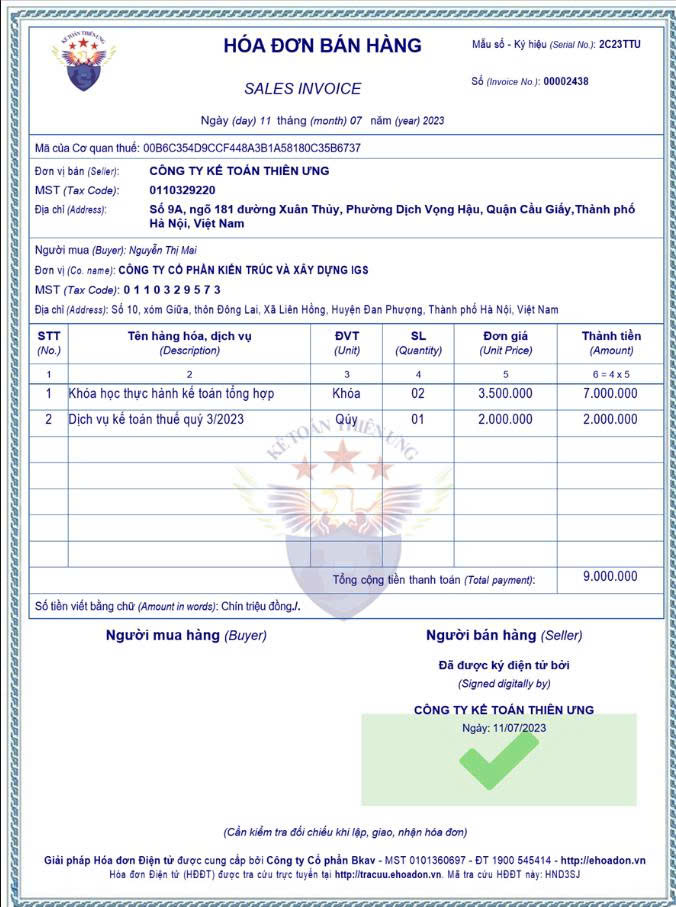

In [5]:
image = Image.open(IMAGE_PATH).convert("RGB")
print(f"Kích thước ảnh: {image.width} x {image.height}")
display(image)

In [6]:
# Lần chạy đầu tiên sẽ tải model nhận dạng vào data/models/easyocr.
reader = easyocr.Reader(
    ["vi", "en"],
    gpu=False,
    model_storage_directory=str(MODEL_DIR),
    download_enabled=True,
)

Using CPU. Note: This module is much faster with a GPU.


In [7]:
results = reader.readtext(
    str(IMAGE_PATH),
    detail=1,
    paragraph=False,
    mag_ratio=1.5,
)

print(f"Nhận diện được {len(results)} vùng văn bản.\n")
for index, (_, text, confidence) in enumerate(results, start=1):
    print(f"{index:03d} | {confidence:.3f} | {text}")

c:\Users\namth\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Nhận diện được 62 vùng văn bản.

001 | 0.016 | nar
002 | 0.999 | HÓA ĐƠN BÁN HÀNG
003 | 0.607 | Máu 88
004 | 0.255 | Ký hiéu (Serial Mo !: 2C2JTTU
005 | 0.424 | S6 (Invoics No | 00002438
006 | 0.996 | SALES INVOICE
007 | 0.684 | Ngảy (day) 11 tháng (month) 07
008 | 0.575 | nám (vear) 2023
009 | 0.262 | Ma cúa Co quan Ihué: 00B6C35EDICCF4484381458180C3586737
010 | 0.364 | Đon YI Dan (Seleri:
011 | 0.709 | CONG TY KÊ TOAN THIEN UNG
012 | 0.862 | MST (Tax Code)
013 | 1.000 | 0110329220
014 | 0.123 | @ja chl (-odress);
015 | 0.639 | S8 9A, ngõ 181
016 | 0.238 | Xuán Thủy, Phường Dịch Vong Hậu, Qu'n Cấu Giấy, Thảnh phố
017 | 0.412 | Hà Nôi, Viêt Nam
018 | 0.300 | Nguói mua (Buyor): Nguyỗn Thỉ Mai
019 | 0.158 | Đon v] (Co mâme) CONG TY CO PHAN KIÊN TRỦC VẢ XẢY DỰNG IGs
020 | 0.519 | MST (Tax Codej: 0 1 1 0 3 2 9 57 3
021 | 0.137 | Đja chi (4ddress): Só 10, xỏm Giúa thón
022 | 0.101 | Lai; Xa Lien Hong Huyen Đan Phưong Thanh phc Hà Nôi Vie: Nam
023 | 0.869 | STT
024 | 0.690 | Tên hàng hỏa, dị

In [8]:
full_text = "\n".join(text for _, text, confidence in results if confidence >= 0.20)
print("VĂN BẢN GỘP:")
print("-" * 80)
print(full_text)

VĂN BẢN GỘP:
--------------------------------------------------------------------------------
HÓA ĐƠN BÁN HÀNG
Máu 88
Ký hiéu (Serial Mo !: 2C2JTTU
S6 (Invoics No | 00002438
SALES INVOICE
Ngảy (day) 11 tháng (month) 07
nám (vear) 2023
Ma cúa Co quan Ihué: 00B6C35EDICCF4484381458180C3586737
Đon YI Dan (Seleri:
CONG TY KÊ TOAN THIEN UNG
MST (Tax Code)
0110329220
S8 9A, ngõ 181
Xuán Thủy, Phường Dịch Vong Hậu, Qu'n Cấu Giấy, Thảnh phố
Hà Nôi, Viêt Nam
Nguói mua (Buyor): Nguyỗn Thỉ Mai
MST (Tax Codej: 0 1 1 0 3 2 9 57 3
STT
Tên hàng hỏa, dịch vụ
ĐVT
Đơn giá
Thánh tièn
(No.)
(Description)
(Unit)
(Quantity)
(Unit Price)
(Amount)
=4x 5
Khoa học thực hảnh ké toản tóng hợp
Khóa
3.500,.000
7.000.000
Dịch vụ kẻ toán thue quỷ 3/2023
K Qúy
2.000.000
2.000.000
công hiên thanh loan (Total payment):
9.000.000
Người mua hàng (Buyer)
Người bán
(Seller)
Đã dược ký diện tử bởi
(Signed aigitally by)
CỒNG TY KÊ TOÁN THIẺN UNG
Ngảy: 11/07/2023
Giải pháp Hóa don Điện Iử đuợc cung cap bởi Cóng ty Cổ phẩn Bkav 

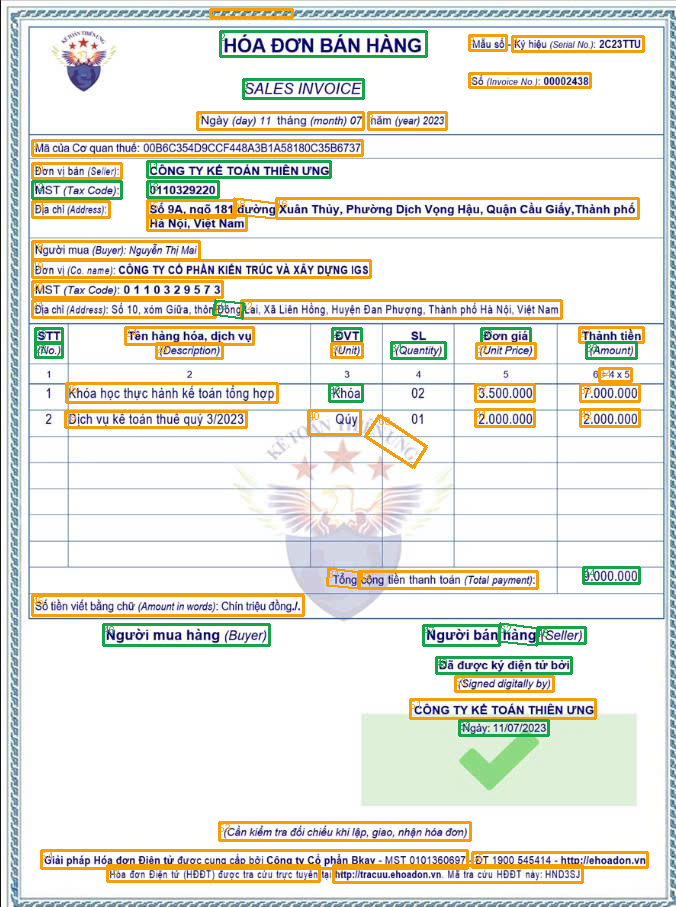

In [9]:
annotated = image.copy()
draw = ImageDraw.Draw(annotated)

for index, (box, _, confidence) in enumerate(results, start=1):
    points = [(int(x), int(y)) for x, y in box]
    color = "#16a34a" if confidence >= 0.70 else "#f59e0b"
    draw.line(points + [points[0]], fill=color, width=3)
    draw.text(points[0], str(index), fill=color)

display(annotated)

In [10]:
import json

OUTPUT_PATH = PROJECT_ROOT / "data" / "output" / "Hoa_don_dien_tu.easyocr.json"
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

ocr_output = {
    "source_file": str(IMAGE_PATH),
    "languages": ["vi", "en"],
    "total_regions": len(results),
    "full_text": "\n".join(text for _, text, _ in results),
    "items": [
        {
            "bbox": [[int(x), int(y)] for x, y in box],
            "text": text,
            "confidence": round(float(confidence), 6),
        }
        for box, text, confidence in results
    ],
}

with OUTPUT_PATH.open("w", encoding="utf-8") as file:
    json.dump(ocr_output, file, ensure_ascii=False, indent=2)

print("Đã lưu:", OUTPUT_PATH)

Đã lưu: D:\NguyenHoangHa_nam4\MLAI\Accounting Agent\code\document\InvoiceReferee\data\output\Hoa_don_dien_tu.easyocr.json
